Cloning into 'GreenPulse'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 55 (delta 16), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 15.17 MiB | 7.71 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 534M/534M [00:28<00:00, 19.7MB/s]

Extracting files...


/kaggle/input/plantvillage-dataset
/root/.cache/kagglehub/datasets/karagwaanntreasure/plant-disease-detection/versions/1
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 1.01G/1.01G [00:49<00:00, 22.2MB/s]

Extracting files...


Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Cocoa_Healthy: 3344 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Tomato_Leaf_Mold: 952 unique images
  └─ Tomato_Healthy: 1585 unique images
  └─ Cocoa_Black_Pod_Rot: 943 unique images
  └─ Maize_Common_Rust: 2144 unique images
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Tomato_Early_Blight: 1000 unique images
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Cocoa_Pod_Borer: 103 unique images


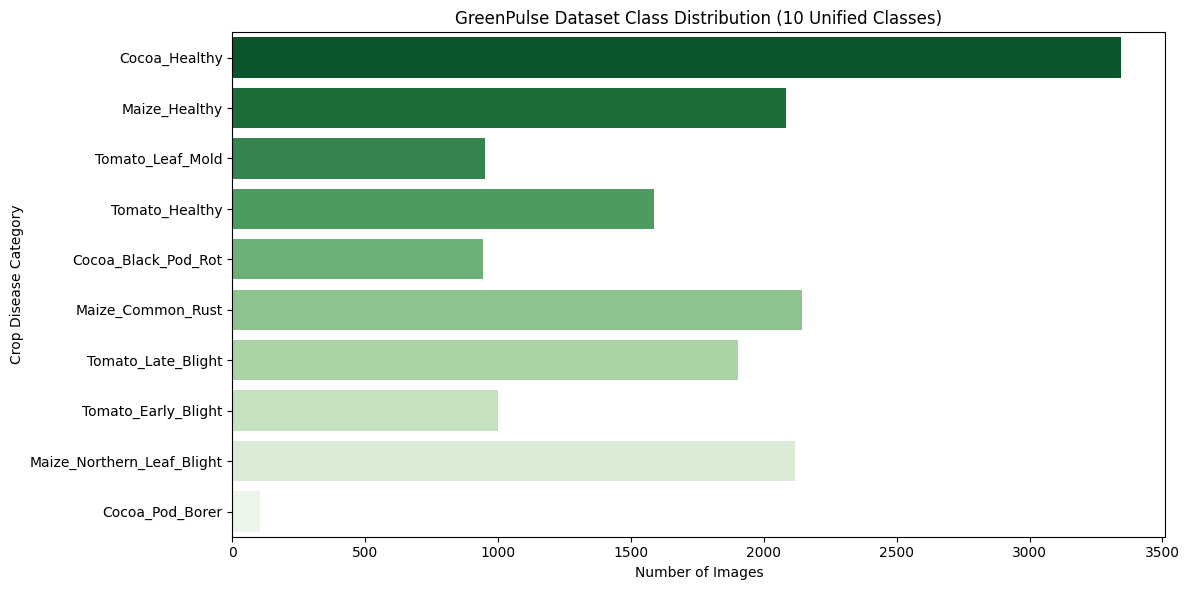

CUDA available: True
GPU: Tesla T4
True
Using device: cuda
GPU: Tesla T4
['Cocoa_Black_Pod_Rot', 'Cocoa_Healthy', 'Cocoa_Pod_Borer', 'Maize_Common_Rust', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold']
16172
Train: 11320
Validation: 2425
Test: 2427
Training images: 11320
Validation images: 2425
Test images: 2427
Training batches: 354
Validation batches: 76
Test batches: 76


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([32, 3, 224, 224])
torch.Size([32])
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 88.7MB/s]


Trainable parameters:
 classifier.0.weight
 classifier.0.bias
 classifier.3.weight
 classifier.3.bias
Epoch  1/5 | train loss 0.682 acc 0.836 | val loss 0.267 acc 0.920
Epoch  2/5 | train loss 0.231 acc 0.933 | val loss 0.183 acc 0.939
Epoch  3/5 | train loss 0.178 acc 0.941 | val loss 0.155 acc 0.949
Epoch  4/5 | train loss 0.150 acc 0.951 | val loss 0.150 acc 0.947
Epoch  5/5 | train loss 0.138 acc 0.954 | val loss 0.139 acc 0.955
{'train_loss': [0.6815555452879242, 0.2312959857521967, 0.17782312015551982, 0.14987477635958169, 0.13809144177306246], 'train_acc': [0.8360424028268552, 0.9326855123674912, 0.9412544169611308, 0.9507950530035336, 0.9539752650176678], 'val_loss': [0.2667954191104653, 0.1829991599948136, 0.15479528693501482, 0.15019116851318742, 0.13896452529605516], 'val_acc': [0.9204123711340206, 0.9385567010309278, 0.9488659793814433, 0.9472164948453609, 0.9554639175257732]}
True
Model size: 16.28 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
%run notebooks/00_data_exploration_and_cleaning.ipynb
%run notebooks/01_model_training.ipynb

In [2]:
import torch
import numpy as numpy
import matplotlib.pyplot as plt

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device: ", device)

Using device:  cuda


In [7]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.mobilenet_v3_large(weights=None)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    10
)

model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [9]:
all_labels = []
all_predictions = []

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

print("True labels:", len(all_labels))
print("Predictions:", len(all_predictions))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


True labels: 2427
Predictions: 2427
